# 牛顿法与优化进阶
## 前言
1. 如何理解信息的价值,永远伴随这计算的成本?
 	 - 梯度下降 斜率(一阶) 便宜但走的慢
    - 牛顿法,斜率 曲率(二阶) 但是贵到离谱(Hessian)

2. 没有最好的算法,只有最合适当前资源限制的算法
    - 当维度高达无法承受的时候,使用BRGS,L-BFGS近似 存储成本**8TB** 时间负杂度 **O^3**
    - Adam 一阶方法 原因:不是因为理论收敛最快,而是算力,内存,效果 找到的best balance

3. 确定性有时会困住你,而"**噪声**"反而可能救命?
    - 牛顿法到达了鞍点,可能被认为到了起始点, 反而梯度下降(SGD[随机采样]),往往会跳过这些鞍点

**提示**: 做任何的决策或近似，都必须要有**量化风险的意识**，而不是稀里糊涂地“差不多就行”"

## 优化算法历程
### 优化中的牛顿法: 对导数,再做一次牛顿法求根
   ####  函数最小值
   函数取得最小值的位置 $x^*$，通常满足：$f'(x^*)=0$
   通过求解：$f'(x)=0$来寻找函数的极值点。

### 牛顿-拉弗森方法（Newton-Raphson Method） (主要目的**求根**)
  - 实现思想:
    牛顿-拉弗森方法是一种通过不断迭代来求解方程$f(x)=0$的方法。
  - 求解过程
    1. 在 $x_n$ 处对 $f(x)$ 做一阶泰勒展开:
    $f(x) \approx f(x_n) + f'(x_n)(x-x_n)$ 令线性近似等于 $0$：
       $$f(x_n) + f'(x_n)(x-x_n)=0$$
    2. 得到下一次迭代值
    $$\boxed{x_{n+1}=x_n-\frac{f(x_n)}{f'(x_n)}}$$
  - 应用范围
    - 卫星轨道方程,开普勒方程

### 康托洛维奇
   - 核心思想:
        起步离根**不太远**,导数不太**病态**,牛顿法是**局部二阶收敛**--误差近似按照平方收敛 (快)

   - 作用
     - 康托洛维奇理论说明，在满足一定条件时，牛顿法能够保证收敛,牛顿法在根附近通常收敛非常快。。
   - 必要条件
        1. 起步离根不太远
           初始值 $x_0$ 需要处于真实根附近。
        2. 导数不太病态
           $f'(x)$ 不能接近 $0$，并且函数在根附近需要足够光滑,不能有鞍点
     3. 牛顿法具有局部二阶收敛
           当 $x_n$ 已经足够接近真实根 $x^*$ 时：
                $$
                    \boxed{
                    e_{n+1}\approx C e_n^2
                    }
                    $$
   - 举例
      - 1e-3 =>  1e-6 按照**平方**缩小误差
### 路德维希·奥托·黑塞（Ludwig Otto Hesse，19世纪德国数学家）
   - **一维中的二阶信息**
      对函数 $f(x)$，二阶导数为：$f''(x)$,描述函数在当前位置的**曲率变化**

   - **多维情况**
      对多变量函数，不仅要考虑每个方向上的二阶偏导数，
      还要考虑不同方向之间的交叉影响。

      例如二元函数 $f(x,y)$：

     $$
      \frac{\partial^2 f}{\partial x^2},
      \qquad
      \frac{\partial^2 f}{\partial x\partial y},
      \qquad
      \frac{\partial^2 f}{\partial y\partial x},
      \qquad
      \frac{\partial^2 f}{\partial y^2}
      $$

   - **Hessian 海森矩阵**

      将所有二阶偏导数组织成矩阵：

      $$
      H =
      \begin{bmatrix}
      \frac{\partial^2 f}{\partial x_1^2}
      &
      \frac{\partial^2 f}{\partial x_1\partial x_2}
      &
      \cdots
      \\[6pt]
      \frac{\partial^2 f}{\partial x_2\partial x_1}
      &
      \frac{\partial^2 f}{\partial x_2^2}
      &
      \cdots
      \\
      \vdots
      &
      \vdots
      &
      \ddots
      \end{bmatrix}
      $$

      这个矩阵称为 **Hessian 矩阵（海森矩阵）**。

### BFGS、L-BFGS
   - 问题: 牛顿法需要计算和存储 Hessian 矩阵：$H(x)$当参数维度很大时，Hessian 矩阵的存储和计算成本非常高。
   - BFGS
    BFGS 不直接计算 Hessian 矩阵，而是通过历史信息不断更新 Hessian 的近似：

   $$
    H_k \approx \nabla^2 f(x_k)
    $$

   或者维护其逆矩阵：

   $$
    B_k \approx H_k^{-1}
   $$

   利用前后两次迭代的信息：

   $$
    s_k=x_{k+1}-x_k
    $$

   $$
    y_k=\nabla f(x_{k+1})-\nabla f(x_k)
   $$

   不断更新 Hessian 的近似矩阵。

 - L-BFGS

    L-BFGS（Limited-memory BFGS）是 BFGS 的低内存版本。

    它不显式存储完整的 Hessian 矩阵，而是只保存最近 $m$ 次迭代的信息：
	$$(s_{k-m},y_{k-m}),\ldots,(s_{k-1},y_{k-1}) $$
    通过这些历史信息计算牛顿方向。因此:
   		$$\boxed{\text{L-BFGS}=\text{只保存有限的历史信息} }$$
    而不是：
    	$$\boxed{\text{直接存储完整 Hessian 矩阵} }$$
 - 应用实例
    - sklearn 逻辑回归 slover = 'lbfgs'


### 卡马 (Kingma)（2014）—— Adam
Adam（Adaptive Moment Estimation）是一种基于**一阶梯度**的优化算法。
	$$\boxed{\text{Adam}=\text{梯度}+\text{动量}+\text{自适应学习率}}$$
#### 核心思想
Adam 不需要计算 Hessian 二阶信息，而是只使用一阶梯度：
	$$g_t=\nabla_\theta f(\theta_t)$$

然后分别记录梯度的：

- **一阶矩**：梯度的指数移动平均 → 类似动量
- **二阶矩**：梯度平方的指数移动平均 → 用于自适应调整步长

##### 1. 一阶矩：动量
$$m_t=\beta_1m_{t-1}+(1-\beta_1)g_t$$
它相当于对过去的梯度进行平滑，减少梯度震荡。
##### 2. 二阶矩：自适应步长
$$v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2$$

不同参数的梯度大小不同，因此 Adam 会根据每个参数历史梯度的大小，自动调整对应的更新步长。

##### 3. 偏差修正
由于 $m_0=0,\ v_0=0$，刚开始时会产生偏差，因此进行修正：

$$\hat m_t=\frac{m_t}{1-\beta_1^t}$$
$$\hat v_t=\frac{v_t}{1-\beta_2^t}$$
##### 4. 参数更新
$$\boxed{\theta_{t+1}=\theta_t-\eta\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}}$$
### 总结
   -  牛顿法:直接利用曲率，一步计算出更合适的更新方向
   - 拟牛顿:曲率不直接算，通过历史信息估计
   - Adam：仍然使用一阶梯度，但会根据历史梯度自适应调整步长


### Loss
   1. 梯度下降:只能看到地面的坡度
   2. 牛顿法: 不知看到地面坡度,还可以看到地面的弯曲,改变步长



## 牛顿法
1. 离最优点很远,hessian 不正定,鞍点附近,甚至会发散,比梯度下降更差
2. 一维  X<-x-f'(x)/f''(x)
		- 求根是解f(x) = 0
		- 求最优是解 f'(x) = 0

4. 多维
    $$ x \leftarrow x - H^{-1}\nabla f(x)$$

    - $x$：当前参数
    - $H$：Hessian 矩阵
    - $H^{-1}$：Hessian 矩阵的逆
    - $\nabla f(x)$：函数在 $x$ 处的梯度

(高斯消元近似方程组 )

- 牛顿法奔着梯度等于0去的

1. 一维从哪里来?
    $f(x)=(x-3)^2+1$
    $f'(x)=2x-6$
    $f''(x)=2$
   $$
x_0=0
\Rightarrow
x_1
=
0-\frac{2(0-3)}{2}
=
3
$$

    ---

    $f(x)=\frac{x^4}{4}-\frac{x^2}{2}$
    $f'(x)=x^3-x=x(x^2-1)=x(x+1)(x-1)$
    驻点:$-1,\quad0,\quad1$
    $f''(x)=3x^2-1$
    在 $-1,1$ 处：$f''(\pm1)=2>0$极小值。
    在 $0$ 处：$f''(0)=-1<0$极大值。

    牛顿法：
    $x_0=0.8\Rightarrow1$
    $x_0=0.1\Rightarrow$取极大值。

2. 二维病态碗
$$
f(x,y)=x^2+10y^2
$$

梯度：

$$
\nabla f=(2x,20y)
$$

$$
H=\operatorname{diag}(2,20)
$$

牛顿法一步：

$$
(0,0)
$$

梯度下降：

$$
\eta=0.08
$$

$y$ 方向每步：
$y_{t+1}=(1-20\eta)y_t=(1-1.6)y_t=-0.6y_t$变号震荡。

### 牛顿法实际运用

   1. 逻辑回归,广义线性模型:sklearn 常用lbfgs 或者 newton-cg
        -Scipy.optimize.minimize(method='BFGS')
   2. L-BFGS-B 把函数最小化交给库,拟合,校准,反演

   3. 视觉与SLAM里面的Bundle Adjustment,相机标定:高斯牛顿/Levenberg-Marquardt,牛顿法在最小二乘的表亲

   4. PyTorch 里面有 torch.optim.LBFGS  适合参数不多,loss光滑的小问题,不太适合训练大模型

   5. XGBoost(Extreme Gradient Boosting) 极端梯度提升
        - 原型: GBDT 梯度提升树
        	-  本质是加法模型: 训练一堆小树,不断拟合上一轮的残差,所有树的预测结果加到一起得到最终预测
            - GBDT使用的是**一阶导数**(梯度)来优化损失
        - XGBoost:最大升级,使用**二阶泰勒**展开
        - 同时使用了一阶导 g,二阶导 h
      	$$L^{(t)}\approx\sum_i\left[g_i w_i+\frac{1}{2}h_i w_i^2\right]+\Omega(f_t)$$

		| 符号                    | 含义                        |
		| --------------------- | ------------------------- |
		| $L^{(t)}$             | 第 $t$ 棵树加入之后的目标函数         |
		| $w_i$                 | 第 $i$ 个样本对应叶子的权重          |
		| $g_i$                 | 损失函数对当前预测值的一阶导数，即梯度       |
		| $h_i$                 | 损失函数对当前预测值的二阶导数，即 Hessian |
		| $\sum_i$              | 对所有训练样本求和                 |
		| $\Omega(f_t)$         | 第 $t$ 棵树的正则化项             |
		| $\frac{1}{2}h_iw_i^2$ | 二阶泰勒展开中的二阶项               |

		- 优点
	        - 分裂节点的与排序 (工程加速)
	        - 缺失值自动处理
	        - 支持并行计算 (树的迭代是**串行**的,并行只发生在一颗树内部分裂,多棵树找的是最优分割点 )
	        - 适用于结构化表格数据(鲁棒性好),图像文本处理不了
	        - 量化中可做因子筛选

#### 深度学习的主场为什么是Adam,不是牛顿?
   1. 没有办法存储
   2. 有噪声
   3. 鞍点太多
   4. 非凸,没法二阶导
   5. 使用一阶相对便宜
#### 牛顿法并非失败,而是问题的尺度换了
- 在sklearn 和scipy中常见,LM论文极少遇见




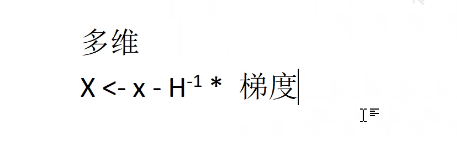
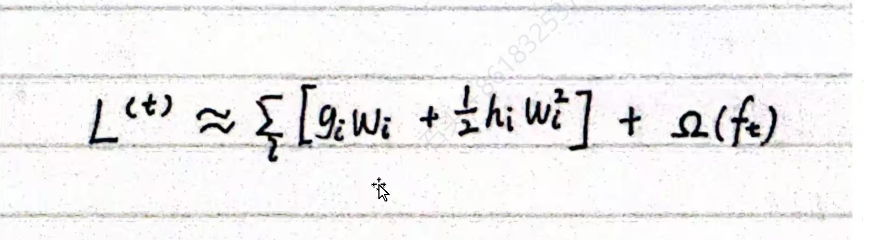

In [1]:
#TODO
"""
    作业1: 牛顿法为什么常常显得快?
    作业2: LFBGS 和Adam怎么选择?
    作业3: 什么是收敛半径?
    作业4: 高斯消元是什么?应用
"""




SyntaxError: invalid syntax (3687566724.py, line 7)